# Exercise 2: 
### Hierarchical Clustering (Agglomerative)

For this exercise, we will be using the `zoo.data` dataset which can be found on the UCI Machine Learning Repository, https://archive.ics.uci.edu/dataset/111/zoo

Your task is to prepare/clean the data in `zoo.data` and subsequently the cleaned dataset is to be used in the agglomerative clustering training process.

---

#### Load libraries
Load the necessary libraries for this exercise.

In [13]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

#### Data Preparation / Preprocessing
Perform the necessary preprocessing steps.

In [14]:
column_names = ['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 
                'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 
                'tail', 'domestic', 'catsize', 'type']
df = pd.read_csv('zoo.data', header=None, names= column_names)
df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [15]:
# drop animal name as non-numeric, drop type as this is unsupervised
iloced_df = df.iloc[:,1:17]
iloced_df

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0
98,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
99,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


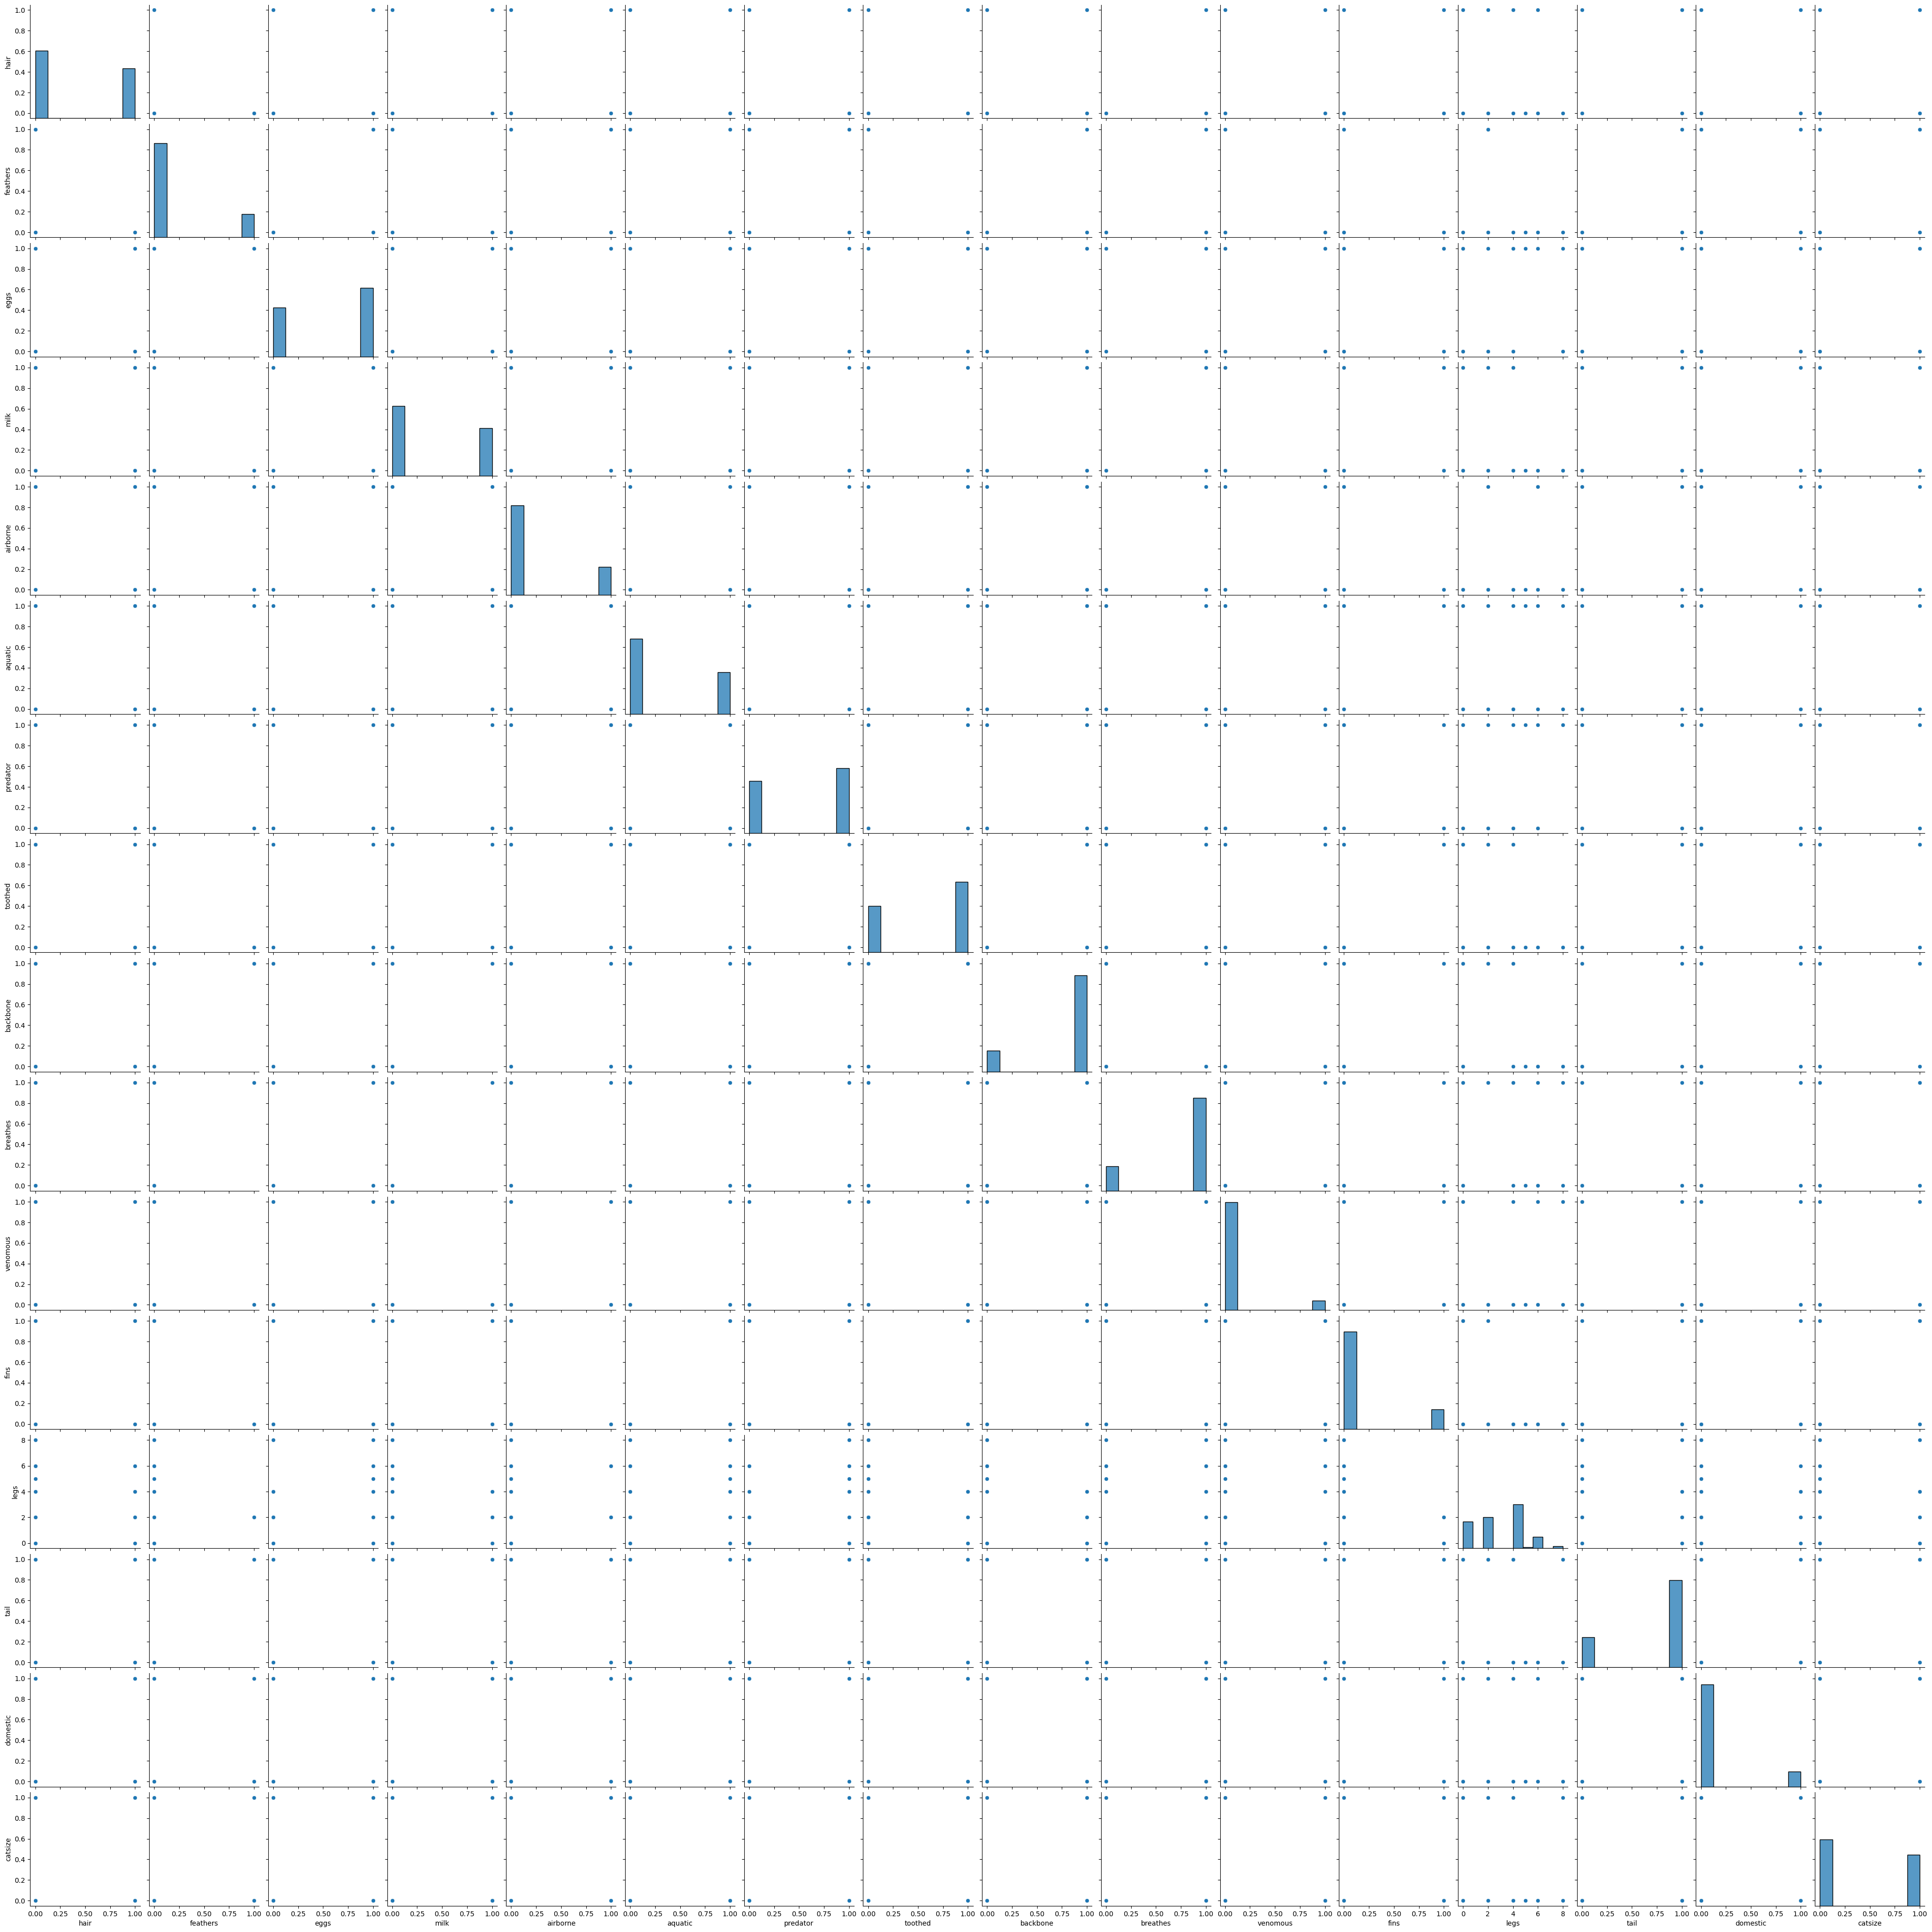

In [4]:
sns.pairplot(iloced_df)

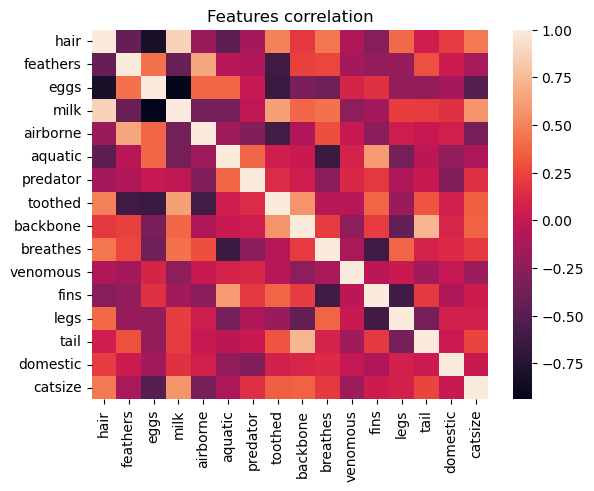

In [16]:
sns.heatmap(iloced_df.corr())
plt.title("Features correlation")
plt.show()

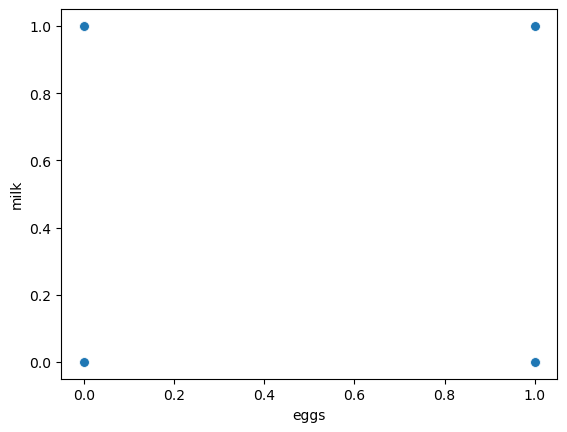

In [17]:
sns.scatterplot(
    x=iloced_df["eggs"], y=iloced_df["milk"], s=50
)
plt.xlabel("eggs")
plt.ylabel("milk")
plt.show()

In [18]:
stdscaler = StandardScaler()

stdscaler.fit(iloced_df)

transformed_df = stdscaler.transform(iloced_df)

scaled_df = pd.DataFrame(transformed_df, columns=iloced_df.columns)
scaled_df.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
1,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
2,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,1.343710,0.896421,0.809776,0.46569,-1.951800,-0.293294,2.222876,-1.404435,0.588784,-0.384353,-0.878595
3,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
4,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180


Text(0, 0.5, 'Distance')

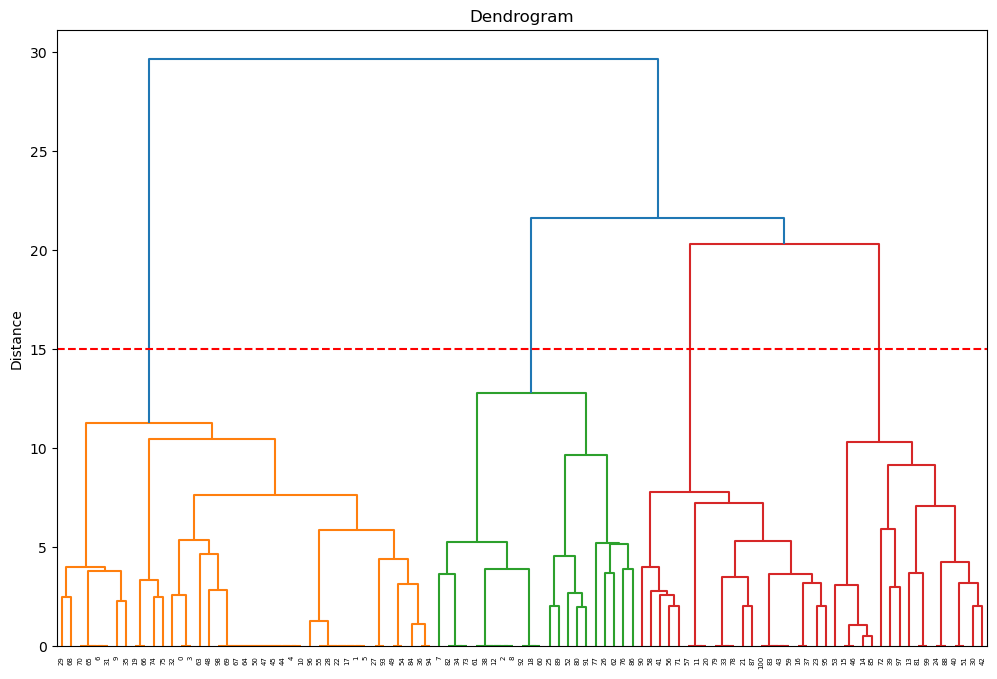

In [19]:
plt.figure(figsize=(12,8))
plt.title("Dendrogram")
dend = dendrogram(linkage(scaled_df, method="ward"))
# 4 clusters looks like a good number
plt.axhline(y=15, color='r', linestyle="--")
plt.ylabel("Distance")

#### Model Training

In [20]:
agglo_cluster = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="ward")
clusters = agglo_cluster.fit_predict(scaled_df)
df["Cluster"] = clusters
df


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type,Cluster
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4,0
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6,2
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7,2


In [21]:
# reduce dimensionality with PCA, reduce to 2

pca = PCA(2)
pca_df = pd.DataFrame(pca.fit_transform(scaled_df))
pca_df.columns = ["PCA1", "PCA2"]
df["PCA1"] = pca_df["PCA1"]
df["PCA2"] = pca_df["PCA2"]
df

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,venomous,fins,legs,tail,domestic,catsize,type,Cluster,PCA1,PCA2
0,aardvark,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,1,2.535256,-0.260278
1,antelope,1,0,0,1,0,0,0,1,1,...,0,0,4,1,0,1,1,1,2.877354,-0.401547
2,bass,0,0,1,0,0,1,1,1,1,...,0,1,0,1,0,0,4,0,-1.761003,3.705592
3,bear,1,0,0,1,0,0,1,1,1,...,0,0,4,0,0,1,1,1,2.535256,-0.260278
4,boar,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,1,2.818975,0.107081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,...,0,0,2,1,0,1,1,1,2.764120,-0.065219
97,wasp,1,0,1,0,1,0,0,0,0,...,1,0,6,0,0,0,6,2,-1.667523,-3.219581
98,wolf,1,0,0,1,0,0,1,1,1,...,0,0,4,1,0,1,1,1,2.818975,0.107081
99,worm,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,7,2,-2.018815,-1.257793


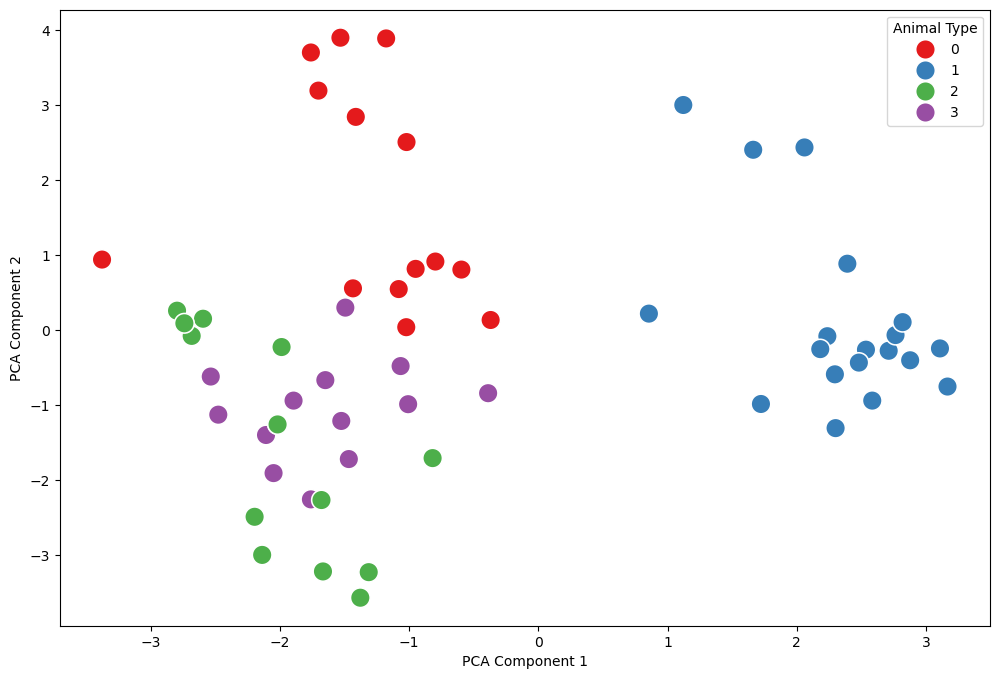

In [22]:
from sklearn.decomposition import PCA

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=200
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Animal Type")